#**Introduction to Computer Vision**
### *Michaela Buchanan - Mark III Systems*



---
Imports for all the code below. Please run this before anything else!


In [2]:
# general
import pandas as pd

# for OD — install PyTorch (CPU) + imageai
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu -q
%pip install opencv-python-headless matplotlib imageai --upgrade -q

from imageai.Detection import ObjectDetection
import cv2
import matplotlib.pyplot as plt

# cv2_imshow replacement for local / non-Colab environments
def cv2_imshow(img):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

# for segmentation
%pip install fastseg -q
from fastseg import MobileV3Large


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.




---
### Introduction


In this notebook, we will be covering the basics of implementing computer vision models in code. Then, we will use libraries that contain pretrained model to explore solving object detection and image segmentation problems using the YOLOv3 and MobileNetv3 algorithms.



---
### Object Detection with YOLOv3


Now that we know how to create our own CV model using Keras, we are going to move on to using pretrained models to solve perform object detection on some images. We are going to be using YOLO-V3 which is a popular OD algorithm. It is ideal for problems that require quick object detection on scenes that do not include very small objects. Below is the code we need to grab our example images out of a GitHub repo I created and the command for downloading the pretrained YOLO-v3 model.

In [1]:
!git clone https://github.com/michaelabuchanan/od_imgs.git
!wget https://github.com/OlafenwaMoses/ImageAI/releases/download/3.0.0-pretrained/yolov3.pt

Cloning into 'od_imgs'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 30 (delta 8), reused 9 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 41.14 MiB | 12.65 MiB/s, done.
Resolving deltas: 100% (8/8), done.
--2026-04-08 16:44:56--  https://github.com/OlafenwaMoses/ImageAI/releases/download/3.0.0-pretrained/yolov3.pt
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/125932201/adc7efe4-b3ac-4710-8a05-0bfefa255bae?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-08T23%3A43%3A57Z&rscd=attachment%3B+filename%3Dyolov3.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-08T22%3A43%3A07Z&ske=2

We are going to be using a library called ImageAI to help us with our object detection. For more information, the documentation for this library can be found [here](https://imageai.readthedocs.io/en/latest/). Below we are going to use an image of some motorcycle racing to see if we can detect the two people and bikes in this image. The printed output below lists the objects found, the confidence level, and the location of the object in the image (ie the bounding box). Below that, you can see the bounding boxes overlayed on the actual image we performed inference on. If you are wondering why 3 people were detected, take a close look at the background. Now we are going to use YOLO on a few more images just as examples before we move to image segmentation.

In [3]:
from imageai.Detection import ObjectDetection
import cv2
detector = ObjectDetection()
detector.setModelTypeAsYOLOv3()
detector.setModelPath('./yolov3.pt')
detector.loadModel()


cat  :  99.76  :  [242, 42, 414, 299]
--------------------------------
cat  :  99.52  :  [366, 54, 590, 307]
--------------------------------
cat  :  99.58  :  [139, 8, 314, 286]
--------------------------------
cat  :  97.95  :  [21, 72, 188, 260]
--------------------------------


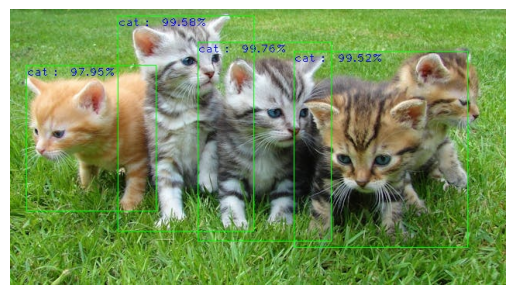

In [4]:
detections = detector.detectObjectsFromImage(input_image='./od_imgs/cats.jpg', output_image_path="./imagenew.jpg", minimum_percentage_probability=30)
for eachObject in detections:
    print(eachObject["name"] , " : ", eachObject["percentage_probability"], " : ", eachObject["box_points"] )
    print("--------------------------------")

img = cv2.imread('imagenew.jpg', cv2.IMREAD_UNCHANGED)
cv2_imshow(img)

Now let's see try another image.

person  :  99.92  :  [544, 152, 600, 246]
--------------------------------
person  :  99.98  :  [746, 82, 778, 159]
--------------------------------
car  :  99.6  :  [88, 181, 392, 374]
--------------------------------


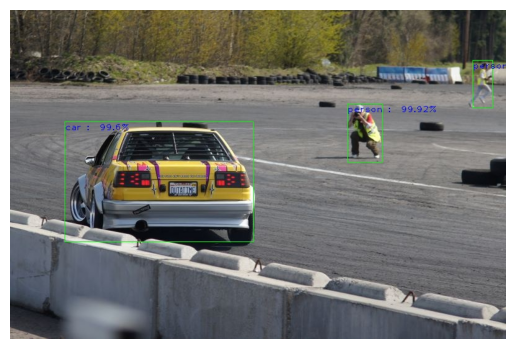

In [5]:
detections = detector.detectObjectsFromImage(input_image='./od_imgs/track-small.jpg', output_image_path="./imagenew2.jpg", minimum_percentage_probability=30)
for eachObject in detections:
    print(eachObject["name"] , " : ", eachObject["percentage_probability"], " : ", eachObject["box_points"] )
    print("--------------------------------")

img2 = cv2.imread('imagenew2.jpg', cv2.IMREAD_UNCHANGED)
cv2_imshow(img2)

Finally let's use a city scene as an example of an image that has a lot of objects to detect in it.

person  :  99.99  :  [326, 332, 384, 480]
--------------------------------
person  :  99.99  :  [463, 311, 496, 408]
--------------------------------
person  :  99.2  :  [851, 377, 900, 503]
--------------------------------
person  :  99.89  :  [666, 420, 736, 505]
--------------------------------
person  :  99.96  :  [436, 301, 468, 403]
--------------------------------
person  :  99.98  :  [538, 370, 587, 493]
--------------------------------
person  :  99.88  :  [646, 368, 698, 501]
--------------------------------
person  :  99.98  :  [822, 285, 865, 402]
--------------------------------
person  :  98.98  :  [514, 351, 547, 413]
--------------------------------
person  :  99.36  :  [843, 289, 868, 377]
--------------------------------
car  :  99.18  :  [345, 266, 440, 333]
--------------------------------
car  :  96.88  :  [38, 286, 180, 408]
--------------------------------
car  :  99.27  :  [247, 259, 321, 322]
--------------------------------
car  :  99.21  :  [167, 264, 267, 34

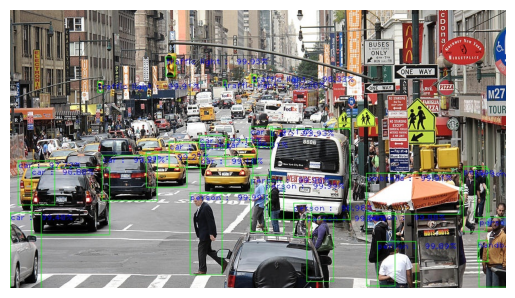

In [6]:
detections = detector.detectObjectsFromImage(input_image='./od_imgs/city.jpg', output_image_path="./imagenew3.jpg", minimum_percentage_probability=30)
for eachObject in detections:
    print(eachObject["name"] , " : ", eachObject["percentage_probability"], " : ", eachObject["box_points"] )
    print("--------------------------------")

img3 = cv2.imread('imagenew3.jpg', cv2.IMREAD_UNCHANGED)
cv2_imshow(img3)



---
### Image Segmentation with MobileV3


To wrap up our workshop, we are going to briefly show how to use the Fastseg library to perform image segmentation on an image. The model we will be using is called MobileNet V3. This model is ideal for situation that require fast performance, such as real-time image segmentation on a self-driving car. We can install Fastseg using `pip` as seen in the first import code block at the beginning of this notebook. See FastSeg's documentation [here](https://github.com/ekzhang/fastseg) for more information.

For this example we are going to try a city road from the perspective of a car driving. While the segmentation is not perfect, it's a pretty good first shot since we haven't messed with fastseg's settings or our image in any way. You can see the road segmented pretty clearly and indications of the sky and trees in the image.

In [ ]:
from fastseg import MobileV3Large
model = MobileV3Large.from_pretrained()
model.eval()

# Open a local image as input
from PIL import Image
image = Image.open('./od_imgs/test.png')

# Predict numeric labels [0-18] for each pixel of the image
labels = model.predict_one(image)

from fastseg.image import colorize, blend

colorized = colorize(labels) # returns a PIL Image
display(image.resize((800, 400)))
display(colorized.resize((800, 400)))

composited = blend(image, colorized) # returns a PIL Image
display(composited.resize((800, 400)))


Loading pretrained model mobilev3large-lraspp with F=128...
Downloading: "https://github.com/ekzhang/fastseg/releases/download/v0.1-weights/mobilev3large-lraspp-f128-9cbabfde.pt" to /Users/ivanp/.cache/torch/hub/checkpoints/mobilev3large-lraspp-f128-9cbabfde.pt


100%|██████████| 25.3M/25.3M [00:02<00:00, 11.1MB/s]


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_mobilenetv3_large_100-427764d5.pth" to /Users/ivanp/.cache/torch/hub/checkpoints/tf_mobilenetv3_large_100-427764d5.pth


AssertionError: Torch not compiled with CUDA enabled